In [1]:
# ========================================
# CELL 1: INSTALL PACKAGES (CẬP NHẬT)
# ========================================
!pip install -q torchaudio transformers soundfile loguru scikit-learn timm

print("✅ Đã cài đặt packages (bao gồm timm)!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 2.1 MB/s eta 0:00:00
✅ Đã cài đặt packages (bao gồm timm)!


In [2]:
# ========================================
# CELL 2: CREATE PROJECT STRUCTURE
# ========================================
import os
import shutil

# Dọn dẹp và tạo thư mục
if os.path.exists("src"):
    shutil.rmtree("src")
os.makedirs("src", exist_ok=True)
os.makedirs("checkpoints", exist_ok=True)

print("✅ Đã làm sạch thư mục dự án.")
print("📁 Cấu trúc thư mục:")
print("   ├── src/")
print("   │   ├── __init__.py")
print("   │   ├── config.py")
print("   │   ├── dataset.py")
print("   │   ├── model.py")
print("   │   ├── utils.py")
print("   │   └── engine.py")
print("   └── checkpoints/")

✅ Đã làm sạch thư mục dự án.
📁 Cấu trúc thư mục:
   ├── src/
   │   ├── __init__.py
   │   ├── config.py
   │   ├── dataset.py
   │   ├── model.py
   │   ├── utils.py
   │   └── engine.py
   └── checkpoints/


In [3]:
# ========================================
# CELL 3: CREATE CONFIG FILE
# ========================================
config_content = """
NUM_CLASSES = 6
EMOTION_MAP = {"ANG": 0, "DIS": 1, "FEA": 2, "HAP": 3, "SAD": 4, "NEU": 5}
DATA_PATH = "" 
CSV_PATH = "./train_dataset.csv"
IMAGE_SIZE = 224
SEQ_LEN = 3
SAMPLE_RATE = 16000
WAVE_TARGET_LEN = 64000

# Training Hyperparameters
BATCH_SIZE = 16
EPOCHS = 25
LR_HEAD = 1e-3
LR_BACKBONE = 1e-4
WEIGHT_DECAY_HEAD = 5e-3
WEIGHT_DECAY_BACKBONE = 1e-3
SEED = 42

# ==========================================
# MODEL SELECTION - CHỈ SỬA 2 DÒNG!
# ==========================================
IMAGE_BACKBONE = "resnet50"  # Options: resnet18, resnet50, darknet53, efficientnet_b3, convnext_tiny, vit_b_16
AUDIO_BACKBONE = "wavlm"      # Options: ast, wavlm, whisper

# Fine-tuning
FREEZE_BACKBONES = True
IMG_UNFREEZE_LAST_BLOCKS = 3
AUDIO_UNFREEZE_LAST_BLOCKS = 3

# Regularization
USE_MIXUP = True
MIXUP_PROB = 0.3
MIXUP_ALPHA = 0.2
LABEL_SMOOTHING = 0.1
EARLY_STOPPING_PATIENCE = 5

# Auto-generated paths
FUSION_TYPE = "crossattn"
MODEL_SAVE_PATH = f"./checkpoints/best_{IMAGE_BACKBONE}_{AUDIO_BACKBONE}.pth"
"""

with open("src/config.py", "w") as f:
    f.write(config_content.strip())

print("✅ Đã tạo file: src/config.py")

from src import config
print(f"\n📋 Experiment Config:")
print(f"   🖼️  Image: {config.IMAGE_BACKBONE.upper()}")
print(f"   🎧 Audio: {config.AUDIO_BACKBONE.upper()}")
print(f"   💾 Save: {config.MODEL_SAVE_PATH}")

✅ Đã tạo file: src/config.py

📋 Experiment Config:
   🖼️  Image: RESNET50
   🎧 Audio: WAVLM
   💾 Save: ./checkpoints/best_resnet50_wavlm.pth


In [4]:
# ========================================
# CELL 4: CREATE DATASET FILE
# ========================================
dataset_content = """
import os
import torch
import cv2
import numpy as np
import soundfile as sf
import torchaudio
from torch.utils.data import Dataset
from torchvision import transforms
from src import config

def add_noise(waveform, noise_level=0.005):
    '''Thêm nhiễu trắng vào audio'''
    if torch.rand(1) < 0.5:
        noise = torch.randn_like(waveform) * noise_level
        return waveform + noise
    return waveform

def load_wav(path, target_sr):
    '''Load và resample audio file'''
    try:
        audio, sr = sf.read(path, dtype="float32", always_2d=False)
        if audio.ndim == 1:
            wav = torch.from_numpy(audio).unsqueeze(0)
        else:
            wav = torch.from_numpy(audio).T.mean(dim=0, keepdim=True)
        if sr != target_sr:
            wav = torchaudio.functional.resample(wav, sr, target_sr)
        return wav
    except Exception as e:
        print(f"Warning: Failed to load {path}: {e}")
        return torch.zeros(1, 64000)

class EmotionDataset(Dataset):
    def __init__(self, data_path, df, is_train=True):
        self.df = df
        self.is_train = is_train
        
        # Image transformations
        if is_train:
            self.tfm = transforms.Compose([
                transforms.ToTensor(),
                transforms.Resize((224, 224), antialias=True),
                transforms.RandomHorizontalFlip(p=0.5),
                transforms.RandomRotation(degrees=10),
                transforms.ColorJitter(brightness=0.1, contrast=0.1),
                transforms.RandomErasing(p=0.1, scale=(0.02, 0.1)),
                transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                                   std=[0.229, 0.224, 0.225])
            ])
        else:
            self.tfm = transforms.Compose([
                transforms.ToTensor(),
                transforms.Resize((224, 224), antialias=True),
                transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                                   std=[0.229, 0.224, 0.225])
            ])

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        
        # Load images
        images = []
        if os.path.exists(str(row["video_frame_dir"])):
            files = sorted(os.listdir(row["video_frame_dir"]))
            
            if len(files) > 3:
                if self.is_train:
                    indices = sorted(np.random.choice(len(files), 3, replace=False))
                else:
                    indices = np.linspace(0, len(files)-1, 3, dtype=int)
                files = [files[i] for i in indices]
            
            for p in files:
                img_path = os.path.join(row["video_frame_dir"], p)
                img = cv2.imread(img_path)
                if img is not None:
                    images.append(self.tfm(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)))
        
        # Padding if needed
        while len(images) < 3:
            images.append(images[-1] if images else torch.zeros(3, 224, 224))
        images = torch.stack(images)

        # Load audio
        wav = load_wav(row["audio_path"], 16000)
        
        # Audio augmentation
        if self.is_train:
            wav = add_noise(wav)
            
        # Trim/Pad audio
        L, T = wav.size(-1), 64000
        if L > T:
            s = np.random.randint(0, L-T+1) if self.is_train else (L-T)//2
            wav = wav[:, s:s+T]
        else:
            wav = torch.nn.functional.pad(wav, (0, T-L))
            
        return images, wav.squeeze(0), torch.tensor(config.EMOTION_MAP[row["emotion"]])
"""

with open("src/dataset.py", "w") as f:
    f.write(dataset_content.strip())

print("✅ Đã tạo file: src/dataset.py")

✅ Đã tạo file: src/dataset.py


In [5]:
# ========================================
# CELL 5: CREATE MODEL FILE (WITH DARKNET-53)
# ========================================
model_content = """
import torch
import torch.nn as nn
import torchvision.models as tv
import timm  # ← THÊM THƯ VIỆN timm
from transformers import (
    AutoFeatureExtractor,
    ASTModel,
    Wav2Vec2Model,
    Wav2Vec2FeatureExtractor,
    WhisperModel,
    WhisperFeatureExtractor
)

# Auto-mapping cho audio models
AUDIO_MODEL_CONFIGS = {
    "ast": {
        "model_id": "MIT/ast-finetuned-audioset-10-10-0.4593",
        "feature_dim": 768,
        "model_class": ASTModel,
        "processor_class": AutoFeatureExtractor
    },
    "wavlm": {
        "model_id": "microsoft/wavlm-base",
        "feature_dim": 768,
        "model_class": Wav2Vec2Model,
        "processor_class": Wav2Vec2FeatureExtractor
    },
    "whisper": {
        "model_id": "openai/whisper-base",
        "feature_dim": 512,
        "model_class": WhisperModel,
        "processor_class": WhisperFeatureExtractor
    }
}

class CrossAttentionFusion(nn.Module):
    def __init__(self, d_a, d_v):
        super().__init__()
        self.attn = nn.MultiheadAttention(256, 4, batch_first=True)
        self.a_proj = nn.Linear(d_a, 256)
        self.v_proj = nn.Linear(d_v, 256)
        self.ln_q = nn.LayerNorm(256)
        self.ln_kv = nn.LayerNorm(256)
        self.out = nn.Linear(256, 256)
        
    def forward(self, a, v):
        q = self.ln_q(self.a_proj(a)).unsqueeze(1)
        kv = self.ln_kv(self.v_proj(v)).unsqueeze(1)
        out, _ = self.attn(q, kv, kv)
        return self.out((q + out).squeeze(1))

class MultimodalEmotionRecognizer(nn.Module):
    def __init__(self, num_classes, fusion, image_backbone, audio_backbone, T):
        super().__init__()
        
        print(f"🏗️  Building: {image_backbone.upper()} + {audio_backbone.upper()}")
        
        # ==========================================
        # IMAGE BACKBONE
        # ==========================================
        if image_backbone == "resnet18":
            print("   📸 Loading ResNet18...")
            rn = tv.resnet18(weights="IMAGENET1K_V1")
            rn.fc = nn.Identity()
            self.visual_net = rn
            visual_feat_dim = 512
            
        elif image_backbone == "resnet50":
            print("   📸 Loading ResNet50...")
            rn = tv.resnet50(weights="IMAGENET1K_V2")
            rn.fc = nn.Identity()
            self.visual_net = rn
            visual_feat_dim = 2048
            
        # ==========================================
        # NEW: DARKNET-53 (via timm)
        # ==========================================
        elif image_backbone == "darknet53":
            print("   📸 Loading Darknet-53...")
            # Load từ timm với pretrained ImageNet
            darknet = timm.create_model('darknet53', pretrained=True, num_classes=0)
            # num_classes=0 → Remove classification head, return features
            self.visual_net = darknet
            visual_feat_dim = 1024  # Darknet-53 output dimension
            print("   ✅ Darknet-53 loaded from timm (ImageNet pretrained)")
            
        elif image_backbone == "efficientnet_b3":
            print("   📸 Loading EfficientNet-B3...")
            eff = tv.efficientnet_b3(weights="IMAGENET1K_V1")
            eff.classifier = nn.Identity()
            self.visual_net = eff
            visual_feat_dim = 1536
            
        elif image_backbone == "convnext_tiny":
            print("   📸 Loading ConvNeXt-Tiny...")
            cnx = tv.convnext_tiny(weights="IMAGENET1K_V1")
            cnx.classifier[2] = nn.Identity()
            self.visual_net = cnx
            visual_feat_dim = 768
            
        elif image_backbone == "vit_b_16":
            print("   📸 Loading ViT-B/16...")
            vit = tv.vit_b_16(weights="IMAGENET1K_V1")
            vit.heads = nn.Identity()
            self.visual_net = vit
            visual_feat_dim = 768
            
        elif image_backbone == "regnet_y_800mf":
            print("   📸 Loading RegNetY-800MF...")
            reg = tv.regnet_y_800mf(weights="IMAGENET1K_V2")
            reg.fc = nn.Identity()
            self.visual_net = reg
            visual_feat_dim = 784
            
        else:
            raise ValueError(f"Unsupported image backbone: {image_backbone}")
        
        self.img_proj = nn.Linear(visual_feat_dim, 128)
        self.img_norm = nn.LayerNorm(128)
        self.image_backbone_type = image_backbone  # ← Store type for utils
        
        # ==========================================
        # AUDIO BACKBONE
        # ==========================================
        if audio_backbone not in AUDIO_MODEL_CONFIGS:
            raise ValueError(f"Unsupported audio backbone: {audio_backbone}")
        
        audio_config = AUDIO_MODEL_CONFIGS[audio_backbone]
        model_id = audio_config["model_id"]
        audio_feat_dim = audio_config["feature_dim"]
        
        print(f"   🎵 Loading {audio_backbone.upper()} from {model_id}...")
        
        self.processor = audio_config["processor_class"].from_pretrained(model_id)
        self.audio_net = audio_config["model_class"].from_pretrained(model_id)
        self.audio_backbone_type = audio_backbone
        
        print(f"   ✅ Audio ready (output dim: {audio_feat_dim})")
        
        # ==========================================
        # FUSION & CLASSIFIER
        # ==========================================
        self.fusion = CrossAttentionFusion(audio_feat_dim, 256)
        self.classifier = nn.Sequential(
            nn.LayerNorm(256),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )
        
        print(f"   🎉 Model built successfully!")

    def forward(self, img, wave):
        # Visual processing
        B, T, C, H, W = img.shape
        v = self.img_norm(self.img_proj(
            self.visual_net(img.view(B*T, C, H, W))
        )).view(B, T, -1)
        v_pool = torch.cat([v.mean(1), v.max(1).values], 1)
        
        # Audio processing
        if wave.dim() == 3:
            wave = wave.squeeze(1)
        
        if self.audio_backbone_type == "ast":
            inputs = self.processor(wave.cpu().numpy(), sampling_rate=16000, 
                                   return_tensors="pt", padding=True)
            inputs = {k: v.to(wave.device) for k, v in inputs.items()}
            audio_out = self.audio_net(**inputs).last_hidden_state
            a = audio_out.mean(dim=1)
            
        elif self.audio_backbone_type == "wavlm":
            inputs = self.processor(wave.cpu().numpy(), sampling_rate=16000, 
                                   return_tensors="pt", padding=True)
            inputs = {k: v.to(wave.device) for k, v in inputs.items()}
            audio_out = self.audio_net(**inputs).last_hidden_state
            a = audio_out.mean(dim=1)
            
        elif self.audio_backbone_type == "whisper":
            inputs = self.processor(wave.cpu().numpy(), sampling_rate=16000, 
                                   return_tensors="pt")
            input_features = inputs.input_features.to(wave.device)
            audio_out = self.audio_net.encoder(input_features).last_hidden_state
            a = audio_out.mean(dim=1)
        
        return self.classifier(self.fusion(a, v_pool))
"""

with open("src/model.py", "w") as f:
    f.write(model_content.strip())

print("✅ Đã tạo file: src/model.py (with Darknet-53)")

✅ Đã tạo file: src/model.py (with Darknet-53)


In [6]:
# ========================================
# CELL 6: CREATE UTILS FILE (WITH DARKNET-53 SUPPORT)
# ========================================
utils_content = """
import torch
import torch.nn as nn

def setup_finetune(model, img_unfreeze_last_blocks=1, audio_unfreeze_last_blocks=1):
    print("🔧 Setting up fine-tuning...")
    
    # Freeze all
    for p in model.parameters():
        p.requires_grad = False
    model.eval()
    
    # Unfreeze head
    for m in [model.img_proj, model.fusion, model.classifier]:
        for p in m.parameters():
            p.requires_grad = True
    
    # ==========================================
    # UNFREEZE IMAGE BACKBONE
    # ==========================================
    visual_net = model.visual_net
    backbone_type = model.image_backbone_type
    
    # ResNet18/50
    if backbone_type in ["resnet18", "resnet50"]:
        if hasattr(visual_net, 'layer1'):
            layers = [visual_net.layer1, visual_net.layer2, 
                      visual_net.layer3, visual_net.layer4]
            if img_unfreeze_last_blocks > 0:
                for blk in layers[-img_unfreeze_last_blocks:]:
                    for p in blk.parameters():
                        p.requires_grad = True
                print(f"   📸 Unfroze last {img_unfreeze_last_blocks} block(s) of {backbone_type.upper()}")
    
    # ==========================================
    # DARKNET-53
    # ==========================================
    elif backbone_type == "darknet53":
        # Darknet-53 structure in timm:
        # stages: [stage0, stage1, stage2, stage3, stage4]
        # stage4 is the deepest
        if hasattr(visual_net, 'stages'):
            stages = visual_net.stages
            if img_unfreeze_last_blocks > 0:
                # Unfreeze last N stages
                for stage in list(stages)[-img_unfreeze_last_blocks:]:
                    for p in stage.parameters():
                        p.requires_grad = True
                print(f"   📸 Unfroze last {img_unfreeze_last_blocks} stage(s) of Darknet-53")
        else:
            # Fallback: try to access blocks
            # timm models có thể có cấu trúc khác
            print("   ⚠️ Darknet-53 structure detection, unfreezing all layers")
            for p in visual_net.parameters():
                p.requires_grad = True
    
    # EfficientNet
    elif backbone_type == "efficientnet_b3":
        if hasattr(visual_net, 'features'):
            blocks = list(visual_net.features.children())
            if img_unfreeze_last_blocks > 0:
                for blk in blocks[-img_unfreeze_last_blocks:]:
                    for p in blk.parameters():
                        p.requires_grad = True
                print(f"   📸 Unfroze last {img_unfreeze_last_blocks} block(s) of EfficientNet")
    
    # ConvNeXt
    elif backbone_type == "convnext_tiny":
        if hasattr(visual_net, 'features'):
            stages = list(visual_net.features.children())
            if img_unfreeze_last_blocks > 0:
                for stage in stages[-img_unfreeze_last_blocks:]:
                    for p in stage.parameters():
                        p.requires_grad = True
                print(f"   📸 Unfroze last {img_unfreeze_last_blocks} stage(s) of ConvNeXt")
    
    # ViT
    elif backbone_type == "vit_b_16":
        if hasattr(visual_net, 'encoder'):
            layers = visual_net.encoder.layers
            if img_unfreeze_last_blocks > 0:
                for layer in layers[-img_unfreeze_last_blocks:]:
                    for p in layer.parameters():
                        p.requires_grad = True
                print(f"   📸 Unfroze last {img_unfreeze_last_blocks} layer(s) of ViT")
    
    # RegNet
    elif backbone_type == "regnet_y_800mf":
        if hasattr(visual_net, 'trunk_output'):
            stages = [visual_net.stem] + list(visual_net.trunk_output.children())
            if img_unfreeze_last_blocks > 0:
                for stage in stages[-img_unfreeze_last_blocks:]:
                    for p in stage.parameters():
                        p.requires_grad = True
                print(f"   📸 Unfroze last {img_unfreeze_last_blocks} stage(s) of RegNet")

    # ==========================================
    # UNFREEZE AUDIO BACKBONE
    # ==========================================
    audio_type = model.audio_backbone_type
    
    if audio_type == "ast":
        if hasattr(model.audio_net, "encoder") and hasattr(model.audio_net.encoder, "layer"):
            layers = model.audio_net.encoder.layer
            if audio_unfreeze_last_blocks > 0:
                for blk in layers[-audio_unfreeze_last_blocks:]:
                    for p in blk.parameters():
                        p.requires_grad = True
                print(f"   🎵 Unfroze last {audio_unfreeze_last_blocks} layers of AST")
    
    elif audio_type == "wavlm":
        if hasattr(model.audio_net, "encoder") and hasattr(model.audio_net.encoder, "layers"):
            layers = model.audio_net.encoder.layers
            if audio_unfreeze_last_blocks > 0:
                for blk in layers[-audio_unfreeze_last_blocks:]:
                    for p in blk.parameters():
                        p.requires_grad = True
                print(f"   🎵 Unfroze last {audio_unfreeze_last_blocks} layers of WavLM")
    
    elif audio_type == "whisper":
        if hasattr(model.audio_net, "encoder") and hasattr(model.audio_net.encoder, "layers"):
            layers = model.audio_net.encoder.layers
            if audio_unfreeze_last_blocks > 0:
                for blk in layers[-audio_unfreeze_last_blocks:]:
                    for p in blk.parameters():
                        p.requires_grad = True
                print(f"   🎵 Unfroze last {audio_unfreeze_last_blocks} layers of Whisper")
    
    # Unfreeze normalization layers
    norm_count = 0
    for name, module in model.named_modules():
        if isinstance(module, (nn.LayerNorm, nn.BatchNorm1d, nn.BatchNorm2d, nn.GroupNorm)):
            if "audio_net" in name or "visual_net" in name:
                for p in module.parameters():
                    p.requires_grad = True
                norm_count += 1
    
    if norm_count > 0:
        print(f"   🔓 Unfroze {norm_count} normalization layers")
    
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model.parameters())
    print(f"   ✅ Trainable: {trainable:,} / {total:,} ({trainable/total*100:.1f}%)")

def build_optimizer(model, lr_head, lr_backbone, wd_head, wd_backbone):
    head_params = (
        list(model.img_proj.parameters()) +
        list(model.fusion.parameters()) +
        list(model.classifier.parameters())
    )
    
    backbone_params = [
        p for p in model.parameters()
        if p.requires_grad and not any(p is pp for pp in head_params)
    ]
    
    return torch.optim.AdamW([
        {"params": head_params, "lr": lr_head, "weight_decay": wd_head},
        {"params": backbone_params, "lr": lr_backbone, "weight_decay": wd_backbone}
    ])
"""

with open("src/utils.py", "w") as f:
    f.write(utils_content.strip())

print("✅ Đã tạo file: src/utils.py (with Darknet-53 support)")

✅ Đã tạo file: src/utils.py (with Darknet-53 support)


In [7]:
# ========================================
# CELL 7: CREATE ENGINE FILE (NO RESTART)
# ========================================
engine_content = """
import torch
import json
import numpy as np
from tqdm import tqdm
from loguru import logger
from torch.optim.lr_scheduler import CosineAnnealingLR  # ← NO RESTART!
from sklearn.metrics import precision_recall_fscore_support

def mixup_data(x_img, x_aud, y, alpha=0.2):
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1.0
    batch_size = x_img.size(0)
    index = torch.randperm(batch_size).to(x_img.device)
    mixed_img = lam * x_img + (1 - lam) * x_img[index]
    mixed_aud = lam * x_aud + (1 - lam) * x_aud[index]
    y_a, y_b = y, y[index]
    return mixed_img, mixed_aud, y_a, y_b, lam

def train(model, train_loader, val_loader, optimizer, criterion, device, 
          epochs, save_path, use_mixup=True, mixup_prob=0.3, mixup_alpha=0.2):
    
    scaler = torch.cuda.amp.GradScaler()
    scheduler = CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)  # ← NO RESTART
    
    best_acc = 0
    patience = 5
    patience_counter = 0
    
    history = {
        "train_acc": [], "train_loss": [],
        "val_acc": [], "val_loss": [],
        "val_precision": [], "val_recall": [], "val_f1": [],
        "learning_rate": []
    }
    
    for ep in range(epochs):
        # TRAINING
        model.train()
        losses, corr, tot = 0, 0, 0
        pbar = tqdm(train_loader, desc=f"Ep {ep+1}/{epochs}")
        
        for img, aud, lbl in pbar:
            img, aud, lbl = img.to(device), aud.to(device), lbl.to(device)
            original_lbl = lbl.clone()
            apply_mixup = use_mixup and (np.random.random() > (1 - mixup_prob))
            
            if apply_mixup:
                img, aud, lbl_a, lbl_b, lam = mixup_data(img, aud, lbl, alpha=mixup_alpha)
                optimizer.zero_grad()
                with torch.cuda.amp.autocast():
                    out = model(img, aud)
                    loss = lam * criterion(out, lbl_a) + (1 - lam) * criterion(out, lbl_b)
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
                _, pred = out.max(1)
                corr += (pred == lbl_a).sum().item()
            else:
                optimizer.zero_grad()
                with torch.cuda.amp.autocast():
                    out = model(img, aud)
                    loss = criterion(out, original_lbl)
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
                _, pred = out.max(1)
                corr += (pred == original_lbl).sum().item()
            
            losses += loss.item()
            tot += original_lbl.size(0)
            pbar.set_postfix({'loss': f'{losses/len(train_loader):.4f}', 'acc': f'{corr/tot:.4f}'})
        
        train_acc = corr / tot
        train_loss = losses / len(train_loader)
        
        # VALIDATION
        model.eval()
        v_losses = 0
        all_preds, all_labels = [], []
        
        with torch.no_grad():
            for img, aud, lbl in val_loader:
                img, aud, lbl = img.to(device), aud.to(device), lbl.to(device)
                out = model(img, aud)
                loss = criterion(out, lbl)
                v_losses += loss.item()
                preds = out.argmax(1)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(lbl.cpu().numpy())
        
        val_acc = np.mean(np.array(all_preds) == np.array(all_labels))
        val_loss = v_losses / len(val_loader)
        precision, recall, f1, _ = precision_recall_fscore_support(
            all_labels, all_preds, average='macro', zero_division=0
        )
        
        history["train_acc"].append(train_acc)
        history["train_loss"].append(train_loss)
        history["val_acc"].append(val_acc)
        history["val_loss"].append(val_loss)
        history["val_precision"].append(float(precision))
        history["val_recall"].append(float(recall))
        history["val_f1"].append(float(f1))
        history["learning_rate"].append(optimizer.param_groups[0]['lr'])
        
        logger.info(
            f"Ep {ep+1}/{epochs} | "
            f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f} | "
            f"P: {precision:.3f} R: {recall:.3f} F1: {f1:.3f}"
        )
        
        if val_acc > best_acc:
            best_acc = val_acc
            patience_counter = 0
            torch.save({
                'model_state': model.state_dict(),
                'epoch': ep + 1,
                'best_acc': best_acc,
                'history': history
            }, save_path)
            logger.info(f"✅ Saved Best Model (Val Acc: {val_acc:.4f})")
        else:
            patience_counter += 1
            if patience_counter >= patience:
                logger.info(f"⚠️ Early stopping at epoch {ep+1}")
                break
        
        scheduler.step()
        logger.info(f"LR: {optimizer.param_groups[0]['lr']:.2e}")
    
    with open("training_history.json", "w") as f:
        json.dump(history, f, indent=2)
    logger.info("✅ Saved training history")
    
    return history
"""

with open("src/engine.py", "w") as f:
    f.write(engine_content.strip())

with open("src/__init__.py", "w") as f:
    f.write("# init")

print("✅ Đã tạo file: src/engine.py")
print("✅ Đã tạo file: src/__init__.py")

✅ Đã tạo file: src/engine.py
✅ Đã tạo file: src/__init__.py


In [8]:
# ========================================
# CELL 8: CREATE DATASET CSV
# ========================================
import pandas as pd
import glob
import os
from src import config

# Đường dẫn Kaggle
AUDIO_DIR = "/kaggle/input/crema-d/cremad/AudioWAV" 
IMAGE_DIR = "/kaggle/input/crema-d/cremad/Image-01-FPS"

print("🔍 Đang quét dữ liệu...")

if os.path.exists(AUDIO_DIR) and os.path.exists(IMAGE_DIR):
    audio_files = glob.glob(os.path.join(AUDIO_DIR, "*.wav"))
    data = []
    VALID = config.EMOTION_MAP.keys()
    
    for path in audio_files:
        filename = os.path.basename(path)
        parts = filename.split("_")
        
        if len(parts) >= 3 and parts[2] in VALID:
            vid_path = os.path.join(IMAGE_DIR, os.path.splitext(filename)[0])
            if os.path.exists(vid_path) and len(os.listdir(vid_path)) > 0:
                data.append({
                    "audio_path": path,
                    "video_frame_dir": vid_path,
                    "emotion": parts[2]
                })
    
    df = pd.DataFrame(data)
    df.to_csv("train_dataset.csv", index=False)
    
    print(f"✅ Tạo CSV thành công: {len(df)} mẫu")
    print(f"\n📊 Phân bố cảm xúc:")
    print(df['emotion'].value_counts().sort_index())
    
else:
    print("❌ Không tìm thấy thư mục input!")
    print("   Hãy kiểm tra: Add Input → crema-d dataset")

🔍 Đang quét dữ liệu...
✅ Tạo CSV thành công: 7442 mẫu

📊 Phân bố cảm xúc:
emotion
ANG    1271
DIS    1271
FEA    1271
HAP    1271
NEU    1087
SAD    1271
Name: count, dtype: int64


In [9]:
# ========================================
# CELL 9: TRAINING (AUTO-DETECT)
# ========================================
import sys, os
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split

sys.path.append(os.getcwd())

from src import config
from src.dataset import EmotionDataset
from src.model import MultimodalEmotionRecognizer
from src.utils import setup_finetune, build_optimizer
from src.engine import train

print("="*70)
print("🚀 BẮT ĐẦU TRAINING")
print("="*70)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"📱 Device: {device}")

if not os.path.exists("train_dataset.csv"):
    print("❌ Chưa có CSV! Chạy Cell 8 trước.")
else:
    df = pd.read_csv("train_dataset.csv")
    print(f"📊 Dataset: {len(df)} samples")
    
    train_df, val_df = train_test_split(
        df, test_size=0.2, stratify=df["emotion"], random_state=42
    )
    
    print(f"   - Train: {len(train_df)} | Val: {len(val_df)}")
    
    train_loader = DataLoader(
        EmotionDataset("", train_df, is_train=True),
        batch_size=config.BATCH_SIZE, shuffle=True,
        num_workers=2, pin_memory=True
    )
    
    val_loader = DataLoader(
        EmotionDataset("", val_df, is_train=False),
        batch_size=config.BATCH_SIZE, shuffle=False,
        num_workers=2, pin_memory=True
    )
    
    print(f"✅ DataLoaders: {len(train_loader)} train, {len(val_loader)} val batches")
    
    # ==========================================
    # CREATE MODEL (TỰ ĐỘNG)
    # ==========================================
    print(f"\n{'='*70}")
    print(f"🧠 EXPERIMENT: {config.IMAGE_BACKBONE.upper()} + {config.AUDIO_BACKBONE.upper()}")
    print(f"{'='*70}\n")
    
    model = MultimodalEmotionRecognizer(
        num_classes=config.NUM_CLASSES,
        fusion=config.FUSION_TYPE,
        image_backbone=config.IMAGE_BACKBONE,  # ← Tự động từ config
        audio_backbone=config.AUDIO_BACKBONE,  # ← Tự động từ config
        T=config.SEQ_LEN
    ).to(device)
    
    print(f"\n{'='*70}")
    setup_finetune(
        model,
        img_unfreeze_last_blocks=config.IMG_UNFREEZE_LAST_BLOCKS,
        audio_unfreeze_last_blocks=config.AUDIO_UNFREEZE_LAST_BLOCKS
    )
    print(f"{'='*70}\n")
    
    optimizer = build_optimizer(
        model, config.LR_HEAD, config.LR_BACKBONE,
        config.WEIGHT_DECAY_HEAD, config.WEIGHT_DECAY_BACKBONE
    )
    
    criterion = nn.CrossEntropyLoss(label_smoothing=config.LABEL_SMOOTHING)
    
    print(f"⚙️  Config:")
    print(f"   - Epochs: {config.EPOCHS} | Batch: {config.BATCH_SIZE}")
    print(f"   - LR: {config.LR_HEAD:.0e} (head), {config.LR_BACKBONE:.0e} (backbone)")
    print(f"   - Mixup: {config.USE_MIXUP} (p={config.MIXUP_PROB}, α={config.MIXUP_ALPHA})")
    print(f"   - Save: {config.MODEL_SAVE_PATH}")
    
    print("\n" + "="*70)
    print("🏃 TRAINING...")
    print("="*70 + "\n")
    
    history = train(
        model=model, train_loader=train_loader, val_loader=val_loader,
        optimizer=optimizer, criterion=criterion, device=device,
        epochs=config.EPOCHS, save_path=config.MODEL_SAVE_PATH,
        use_mixup=config.USE_MIXUP, mixup_prob=config.MIXUP_PROB,
        mixup_alpha=config.MIXUP_ALPHA
    )
    
    print("\n" + "="*70)
    print("✅ DONE!")
    print(f"🏆 Best: {max(history['val_acc']):.4f}")
    print("="*70)

/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

🚀 BẮT ĐẦU TRAINING
📱 Device: cuda
📊 Dataset: 7442 samples
   - Train: 5953 | Val: 1489
✅ DataLoaders: 373 train, 94 val batches

🧠 EXPERIMENT: RESNET50 + WAVLM

🏗️  Building: RESNET50 + WAVLM
   📸 Loading ResNet50...
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 204MB/s]


   🎵 Loading WAVLM from microsoft/wavlm-base...


preprocessor_config.json:   0%|          | 0.00/215 [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/378M [00:00<?, ?B/s]

/kaggle/working/src/engine.py:24: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()



🔧 Setting up fine-tuning...
   📸 Unfroze last 3 block(s) of RESNET50
   🎵 Unfroze last 3 layers of WavLM
   🔓 Unfroze 80 normalization layers
   ✅ Trainable: 45,437,446 / 118,736,966 (38.3%)

⚙️  Config:
   - Epochs: 25 | Batch: 16
   - LR: 1e-03 (head), 1e-04 (backbone)
   - Mixup: True (p=0.3, α=0.2)
   - Save: ./checkpoints/best_resnet50_wavlm.pth

🏃 TRAINING...




Ep 1/25:   0%|          | 0/373 [00:00<?, ?it/s]/kaggle/working/src/engine.py:62: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():

Ep 1/25:   2%|▏         | 6/373 [00:06<04:37,  1.32it/s, loss=0.0392, acc=0.1771]/kaggle/working/src/engine.py:52: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():

Ep 1/25: 100%|██████████| 373/373 [03:36<00:00,  1.72it/s, loss=1.6327, acc=0.3392]
2026-01-03 04:26:59.959 | INFO     | src.engine:train:108 - Ep 1/25 | Train Loss: 1.6327 Acc: 0.3392 | Val Loss: 1.3642 Acc: 0.4795 | P: 0.586 R: 0.469 F1: 0.446
2026-01-03 04:27:00.476 | INFO     | src.engine:train:124 - ✅ Saved Best Model (Val Acc: 0.4795)
2026-01-03 04:27:00.477 | INFO     | src.engine:train:132 - LR: 9.96e-04
Ep 2/25:   0%|          | 0/373 [00:00<?, ?it/s]/kaggle/working/src/en


✅ DONE!
🏆 Best: 0.8805


📊 ĐANG TẠO BIỂU ĐỒ...


/tmp/ipykernel_23/2189161119.py:135: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.savefig("training_metrics_full.png", dpi=300, bbox_inches='tight')
/tmp/ipykernel_23/2189161119.py:135: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.savefig("training_metrics_full.png", dpi=300, bbox_inches='tight')
/tmp/ipykernel_23/2189161119.py:135: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.savefig("training_metrics_full.png", dpi=300, bbox_inches='tight')
/tmp/ipykernel_23/2189161119.py:135: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.savefig("training_metrics_full.png", dpi=300, bbox_inches='tight')
/tmp/ipykernel_23/2189161119.py:135: UserWarning: Glyph 128218 (\N{BOOKS}) missing from font(s) DejaVu Sans.
  plt.savefig("training_metrics_full.png", dpi=300, bbox_inches='tight')
/tmp/ipykernel_23/21

✅ Đã lưu: training_metrics_full.png


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128218 (\N{BOOKS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


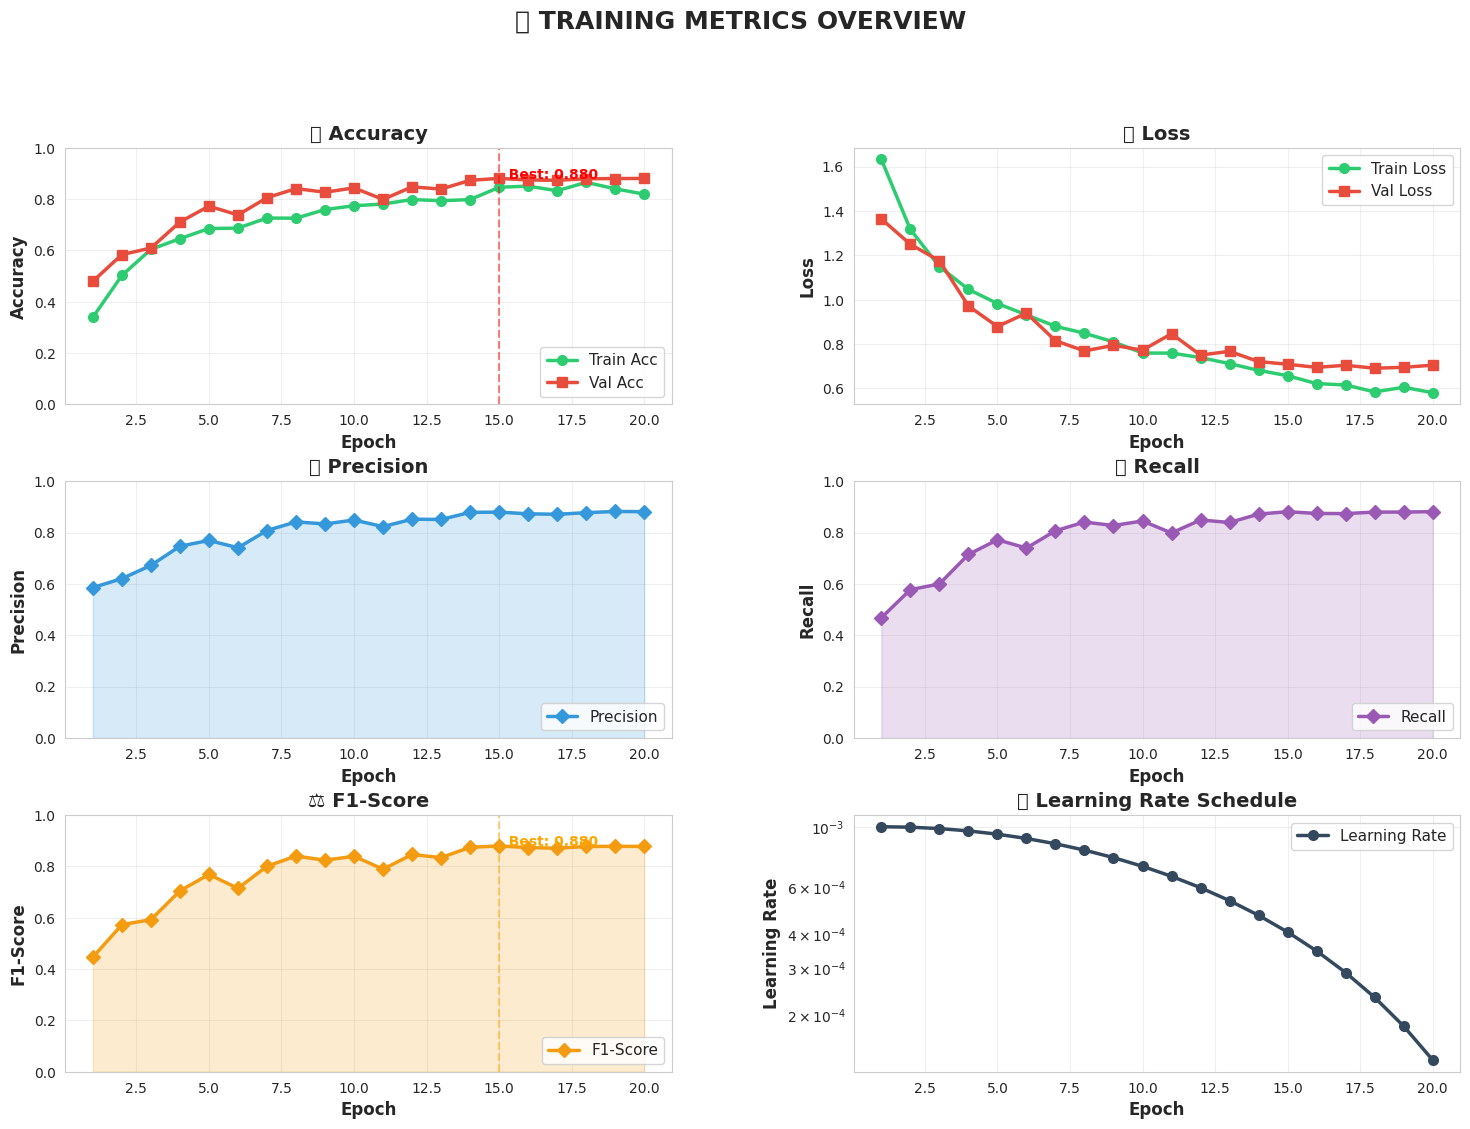

/tmp/ipykernel_23/2189161119.py:160: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_23/2189161119.py:161: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.savefig("precision_recall_f1_comparison.png", dpi=300, bbox_inches='tight')


✅ Đã lưu: precision_recall_f1_comparison.png


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


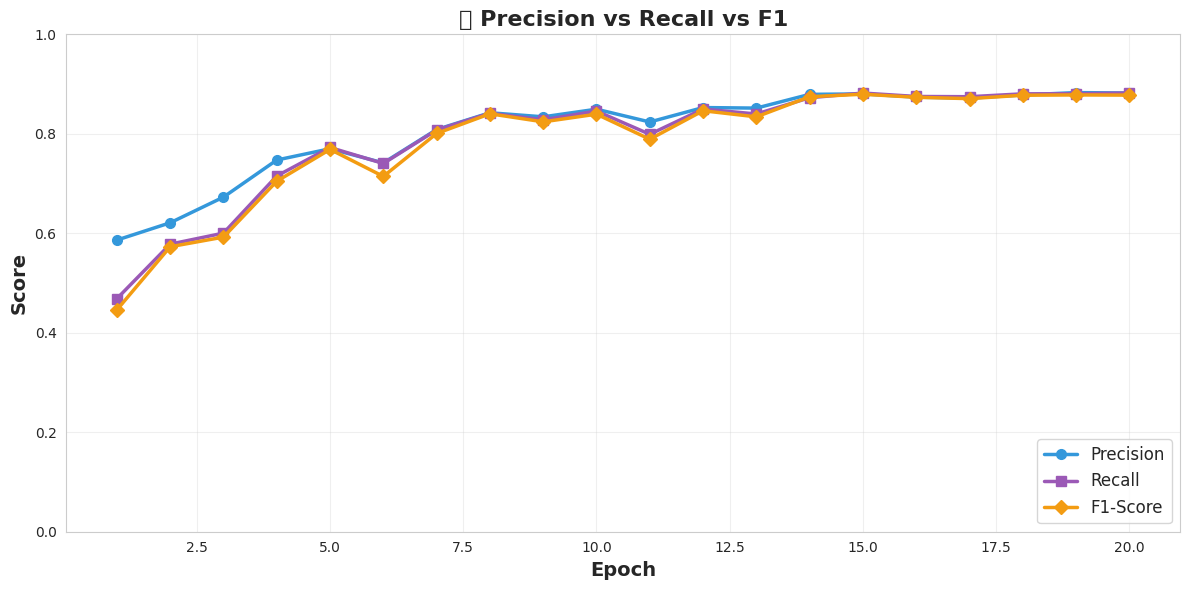


📈 TỔNG KẾT TRAINING
Best Val Accuracy:  0.8805 (Epoch 15)
Best Val F1-Score:  0.8796 (Epoch 15)
Final Val Precision: 0.8820
Final Val Recall:    0.8820
Final Val Accuracy:  0.8805
Total Epochs:        20


In [10]:
# ========================================
# CELL 10: PLOT TRAINING METRICS
# ========================================
import json
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib import gridspec

def plot_training_metrics():
    print("📊 ĐANG TẠO BIỂU ĐỒ...")
    
    # Load history
    if not os.path.exists("training_history.json"):
        print("❌ Không tìm thấy training_history.json")
        return
    
    with open("training_history.json", "r") as f:
        history = json.load(f)
    
    epochs = range(1, len(history["train_acc"]) + 1)
    
    # Create figure
    fig = plt.figure(figsize=(18, 12))
    gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.3, wspace=0.3)
    
    sns.set_style("whitegrid")
    colors = {
        'train': '#2ecc71',
        'val': '#e74c3c',
        'precision': '#3498db',
        'recall': '#9b59b6',
        'f1': '#f39c12'
    }
    
    # 1. Accuracy
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.plot(epochs, history["train_acc"], 
             marker='o', linewidth=2.5, markersize=7,
             color=colors['train'], label='Train Acc')
    ax1.plot(epochs, history["val_acc"], 
             marker='s', linewidth=2.5, markersize=7,
             color=colors['val'], label='Val Acc')
    ax1.set_xlabel('Epoch', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
    ax1.set_title('📈 Accuracy', fontsize=14, fontweight='bold')
    ax1.legend(loc='lower right', fontsize=11)
    ax1.grid(True, alpha=0.3)
    ax1.set_ylim([0, 1])
    
    # Mark best epoch
    best_epoch = np.argmax(history["val_acc"]) + 1
    best_acc = max(history["val_acc"])
    ax1.axvline(x=best_epoch, color='red', linestyle='--', alpha=0.5)
    ax1.text(best_epoch, best_acc, f'  Best: {best_acc:.3f}', 
             fontsize=10, color='red', fontweight='bold')
    
    # 2. Loss
    ax2 = fig.add_subplot(gs[0, 1])
    ax2.plot(epochs, history["train_loss"], 
             marker='o', linewidth=2.5, markersize=7,
             color=colors['train'], label='Train Loss')
    ax2.plot(epochs, history["val_loss"], 
             marker='s', linewidth=2.5, markersize=7,
             color=colors['val'], label='Val Loss')
    ax2.set_xlabel('Epoch', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Loss', fontsize=12, fontweight='bold')
    ax2.set_title('📉 Loss', fontsize=14, fontweight='bold')
    ax2.legend(loc='upper right', fontsize=11)
    ax2.grid(True, alpha=0.3)
    
    # 3. Precision
    ax3 = fig.add_subplot(gs[1, 0])
    ax3.plot(epochs, history["val_precision"], 
             marker='D', linewidth=2.5, markersize=7,
             color=colors['precision'], label='Precision')
    ax3.fill_between(epochs, history["val_precision"], alpha=0.2, 
                      color=colors['precision'])
    ax3.set_xlabel('Epoch', fontsize=12, fontweight='bold')
    ax3.set_ylabel('Precision', fontsize=12, fontweight='bold')
    ax3.set_title('🎯 Precision', fontsize=14, fontweight='bold')
    ax3.legend(loc='lower right', fontsize=11)
    ax3.grid(True, alpha=0.3)
    ax3.set_ylim([0, 1])
    
    # 4. Recall
    ax4 = fig.add_subplot(gs[1, 1])
    ax4.plot(epochs, history["val_recall"], 
             marker='D', linewidth=2.5, markersize=7,
             color=colors['recall'], label='Recall')
    ax4.fill_between(epochs, history["val_recall"], alpha=0.2, 
                      color=colors['recall'])
    ax4.set_xlabel('Epoch', fontsize=12, fontweight='bold')
    ax4.set_ylabel('Recall', fontsize=12, fontweight='bold')
    ax4.set_title('🔍 Recall', fontsize=14, fontweight='bold')
    ax4.legend(loc='lower right', fontsize=11)
    ax4.grid(True, alpha=0.3)
    ax4.set_ylim([0, 1])
    
    # 5. F1-Score
    ax5 = fig.add_subplot(gs[2, 0])
    ax5.plot(epochs, history["val_f1"], 
             marker='D', linewidth=2.5, markersize=7,
             color=colors['f1'], label='F1-Score')
    ax5.fill_between(epochs, history["val_f1"], alpha=0.2, 
                      color=colors['f1'])
    ax5.set_xlabel('Epoch', fontsize=12, fontweight='bold')
    ax5.set_ylabel('F1-Score', fontsize=12, fontweight='bold')
    ax5.set_title('⚖️ F1-Score', fontsize=14, fontweight='bold')
    ax5.legend(loc='lower right', fontsize=11)
    ax5.grid(True, alpha=0.3)
    ax5.set_ylim([0, 1])
    
    best_f1_epoch = np.argmax(history["val_f1"]) + 1
    best_f1 = max(history["val_f1"])
    ax5.axvline(x=best_f1_epoch, color='orange', linestyle='--', alpha=0.5)
    ax5.text(best_f1_epoch, best_f1, f'  Best: {best_f1:.3f}', 
             fontsize=10, color='orange', fontweight='bold')
    
    # 6. Learning Rate
    ax6 = fig.add_subplot(gs[2, 1])
    ax6.plot(epochs, history["learning_rate"], 
             marker='o', linewidth=2.5, markersize=7,
             color='#34495e', label='Learning Rate')
    ax6.set_xlabel('Epoch', fontsize=12, fontweight='bold')
    ax6.set_ylabel('Learning Rate', fontsize=12, fontweight='bold')
    ax6.set_title('📚 Learning Rate Schedule', fontsize=14, fontweight='bold')
    ax6.legend(loc='upper right', fontsize=11)
    ax6.grid(True, alpha=0.3)
    ax6.set_yscale('log')
    
    plt.suptitle('🚀 TRAINING METRICS OVERVIEW', 
                 fontsize=18, fontweight='bold', y=0.995)
    
    plt.savefig("training_metrics_full.png", dpi=300, bbox_inches='tight')
    print("✅ Đã lưu: training_metrics_full.png")
    plt.show()
    
    # Comparison plot
    fig2, ax = plt.subplots(figsize=(12, 6))
    
    ax.plot(epochs, history["val_precision"], 
            marker='o', linewidth=2.5, markersize=7,
            color=colors['precision'], label='Precision')
    ax.plot(epochs, history["val_recall"], 
            marker='s', linewidth=2.5, markersize=7,
            color=colors['recall'], label='Recall')
    ax.plot(epochs, history["val_f1"], 
            marker='D', linewidth=2.5, markersize=7,
            color=colors['f1'], label='F1-Score')
    
    ax.set_xlabel('Epoch', fontsize=14, fontweight='bold')
    ax.set_ylabel('Score', fontsize=14, fontweight='bold')
    ax.set_title('📊 Precision vs Recall vs F1', 
                 fontsize=16, fontweight='bold')
    ax.legend(loc='lower right', fontsize=12)
    ax.grid(True, alpha=0.3)
    ax.set_ylim([0, 1])
    
    plt.tight_layout()
    plt.savefig("precision_recall_f1_comparison.png", dpi=300, bbox_inches='tight')
    print("✅ Đã lưu: precision_recall_f1_comparison.png")
    plt.show()
    
    # Print summary
    print("\n" + "="*60)
    print("📈 TỔNG KẾT TRAINING")
    print("="*60)
    print(f"Best Val Accuracy:  {max(history['val_acc']):.4f} (Epoch {np.argmax(history['val_acc'])+1})")
    print(f"Best Val F1-Score:  {max(history['val_f1']):.4f} (Epoch {np.argmax(history['val_f1'])+1})")
    print(f"Final Val Precision: {history['val_precision'][-1]:.4f}")
    print(f"Final Val Recall:    {history['val_recall'][-1]:.4f}")
    print(f"Final Val Accuracy:  {history['val_acc'][-1]:.4f}")
    print(f"Total Epochs:        {len(epochs)}")
    print("="*60)

# Run
plot_training_metrics()

🎭 ĐANG TẠO CONFUSION MATRIX...
Đang tải model từ: ./checkpoints/best_resnet50_wavlm.pth
🏗️  Building: RESNET50 + WAVLM
   📸 Loading ResNet50...
   🎵 Loading WAVLM from microsoft/wavlm-base...


You are using a model of type wavlm to instantiate a model of type wav2vec2. This is not supported for all configurations of models and can yield errors.


   ✅ Audio ready (output dim: 768)
   🎉 Model built successfully!
✅ Loaded model from epoch 15
   Best Val Acc: 0.8805
⏳ Đang đánh giá trên validation set...
✅ Đã lưu: confusion_matrix.png


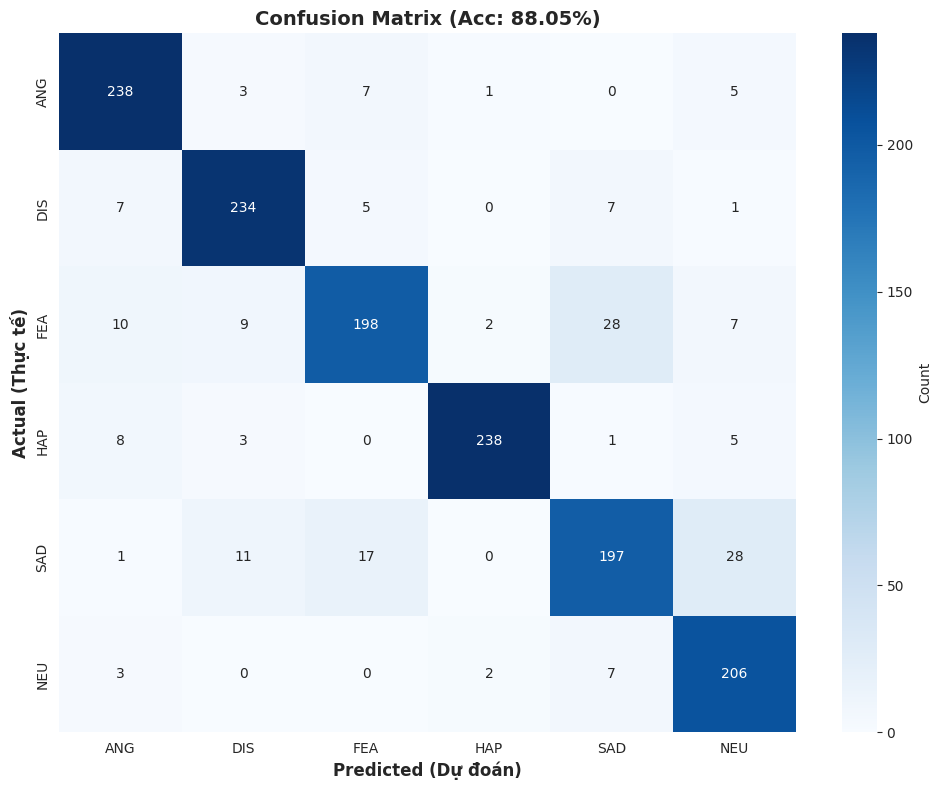


📊 CLASSIFICATION REPORT
              precision    recall  f1-score   support

         ANG     0.8914    0.9370    0.9136       254
         DIS     0.9000    0.9213    0.9105       254
         FEA     0.8722    0.7795    0.8233       254
         HAP     0.9794    0.9333    0.9558       255
         SAD     0.8208    0.7756    0.7976       254
         NEU     0.8175    0.9450    0.8766       218

    accuracy                         0.8805      1489
   macro avg     0.8802    0.8819    0.8796      1489
weighted avg     0.8818    0.8805    0.8797      1489

✅ Đã lưu: classification_report.txt

🔍 PHÂN TÍCH LỖI (TOP NHẦM LẪN)
Mô hình hay nhầm nhất là:
1. Thực tế là FEA nhưng đoán là SAD: 28 mẫu (11.0%)
2. Thực tế là SAD nhưng đoán là NEU: 28 mẫu (11.0%)
3. Thực tế là SAD nhưng đoán là FEA: 17 mẫu (6.7%)
4. Thực tế là SAD nhưng đoán là DIS: 11 mẫu (4.3%)
5. Thực tế là FEA nhưng đoán là ANG: 10 mẫu (3.9%)


In [11]:
# ========================================
# CELL 11: CONFUSION MATRIX & EVALUATION (FIXED)
# ========================================
import torch
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split
import os

# Import modules
from src import config
from src.dataset import EmotionDataset
from src.model import MultimodalEmotionRecognizer

def generate_confusion_matrix():
    print("🎭 ĐANG TẠO CONFUSION MATRIX...")
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    if not os.path.exists(config.MODEL_SAVE_PATH):
        print("❌ Chưa có model! Hãy train trước.")
        return
    
    # 1. Load Data
    if not os.path.exists("train_dataset.csv"):
        print("❌ Không tìm thấy file train_dataset.csv")
        return

    df = pd.read_csv("train_dataset.csv")
    # Chia tập Val giống hệt lúc train
    _, val_df = train_test_split(df, test_size=0.2, 
                                  stratify=df["emotion"], random_state=42)
    
    val_loader = DataLoader(
        EmotionDataset("", val_df, is_train=False),
        batch_size=config.BATCH_SIZE,
        shuffle=False,
        num_workers=2
    )
    
    # 2. Load Model
    print(f"Đang tải model từ: {config.MODEL_SAVE_PATH}")
    
    # --- SỬA LỖI TẠI ĐÂY ---
    # Thay 'ast_model_id' bằng 'audio_backbone' để khớp với src/model.py
    model = MultimodalEmotionRecognizer(
        num_classes=config.NUM_CLASSES,
        fusion=config.FUSION_TYPE,
        image_backbone=config.IMAGE_BACKBONE,
        audio_backbone=config.AUDIO_BACKBONE, # <--- ĐÃ SỬA TÊN THAM SỐ
        T=config.SEQ_LEN
    ).to(device)
    
    # 3. Load Weights
    try:
        checkpoint = torch.load(
            config.MODEL_SAVE_PATH, 
            map_location=device,
            weights_only=False 
        )
        
        if "model_state" in checkpoint:
            model.load_state_dict(checkpoint["model_state"])
            print(f"✅ Loaded model from epoch {checkpoint.get('epoch', '?')}")
            print(f"   Best Val Acc: {checkpoint.get('best_acc', '?'):.4f}")
        else:
            model.load_state_dict(checkpoint)
            print("✅ Loaded model weights")
            
    except Exception as e:
        print(f"❌ Lỗi load model: {e}")
        return
    
    model.eval()
    
    # 4. Get predictions
    all_preds = []
    all_labels = []
    
    print("⏳ Đang đánh giá trên validation set...")
    with torch.no_grad():
        for img, aud, lbl in val_loader:
            img, aud, lbl = img.to(device), aud.to(device), lbl.to(device)
            outputs = model(img, aud)
            preds = torch.max(outputs, 1)[1]
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(lbl.cpu().numpy())
    
    # 5. Visualize Confusion matrix
    emotion_names = [k for k, v in sorted(config.EMOTION_MAP.items(), 
                                          key=lambda item: item[1])]
    
    cm = confusion_matrix(all_labels, all_preds)
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=emotion_names, yticklabels=emotion_names,
                cbar_kws={'label': 'Count'})
    plt.xlabel('Predicted (Dự đoán)', fontsize=12, fontweight='bold')
    plt.ylabel('Actual (Thực tế)', fontsize=12, fontweight='bold')
    
    # Lấy accuracy từ checkpoint nếu có, không thì tính tay
    acc_display = checkpoint.get("best_acc", 0) if isinstance(checkpoint, dict) else 0
    plt.title(f'Confusion Matrix (Acc: {acc_display:.2%})', fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig("confusion_matrix.png", dpi=300, bbox_inches='tight')
    print("✅ Đã lưu: confusion_matrix.png")
    plt.show()
    
    # 6. Classification report
    report = classification_report(all_labels, all_preds, 
                                   target_names=emotion_names, digits=4)
    print("\n" + "="*60)
    print("📊 CLASSIFICATION REPORT")
    print("="*60)
    print(report)
    
    with open("classification_report.txt", "w") as f:
        f.write(report)
    print("✅ Đã lưu: classification_report.txt")
    
    # 7. Error Analysis
    print("\n" + "="*60)
    print("🔍 PHÂN TÍCH LỖI (TOP NHẦM LẪN)")
    print("="*60)
    
    confusions = []
    for i in range(len(emotion_names)):
        for j in range(len(emotion_names)):
            if i != j and cm[i, j] > 0:
                confusions.append((
                    emotion_names[i], 
                    emotion_names[j], 
                    cm[i, j],
                    cm[i, j] / cm[i].sum() * 100
                ))
    
    confusions.sort(key=lambda x: x[2], reverse=True)
    
    print("Mô hình hay nhầm nhất là:")
    for idx, (true_label, pred_label, count, pct) in enumerate(confusions[:5], 1):
        print(f"{idx}. Thực tế là {true_label} nhưng đoán là {pred_label}: {count} mẫu ({pct:.1f}%)")
    
    print("="*60)

# Run
generate_confusion_matrix()